# Logistic Regression and Classification

In [1]:
#sigmoid curve produces an output variable between 0 and 1 

#Logistic Funtion:
# y = 1.0 / (1.0 + e **-(b0 +b1x))

In [3]:
import math 

def predict_probability(x, b0, b1):
    p = 1.0 / (1.0 + exp(-(b0 + b1 * x)))
    
    return p

1.0/(1.0 + 16.8272567955368*exp(-0.62*x))


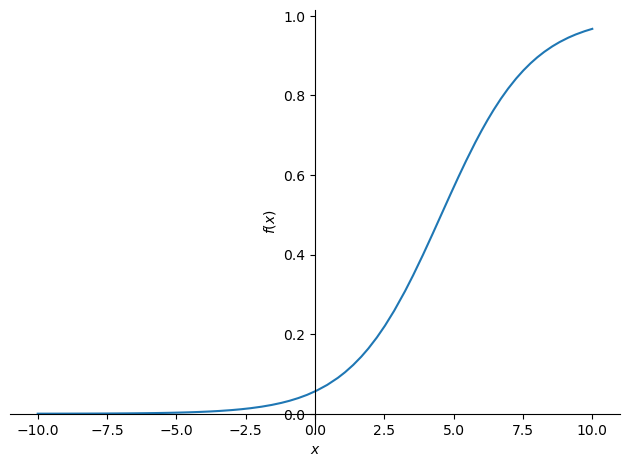

In [5]:
from sympy import *

b0, b1, x = symbols('b0 b1 x')

p = 1.0 / (1.0 + exp(-(b0 + b1 * x)))

p = p.subs(b0, -2.823)
p = p.subs(b1, 0.620)
print(p)
plot(p)

#### 

### Fitting the Logictic Curve 

In [23]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import numpy as np

df = pd.read_csv('https://bit.ly/33ebs2R', delimiter=",")

X = df.values[:,:-1]
Y = df.values[:,-1]

#perform logistic regression
model = LogisticRegression(penalty=None)
model.fit(X,Y)

#beta 1
b1 = model.coef_.flatten()
#beta 0
b0 = model.intercept_.flatten()

print(b1)
print(b0)

[0.69268939]
[-3.17580504]


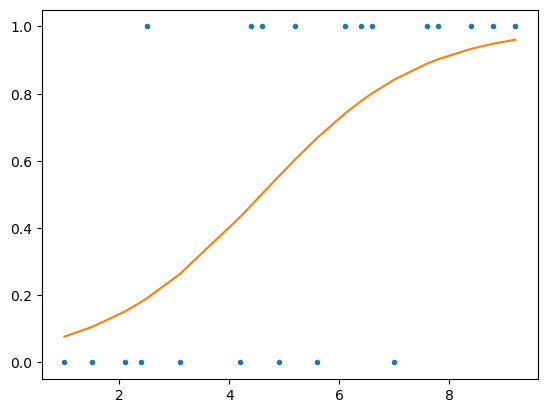

In [34]:
import matplotlib.pyplot as plt

plt.plot(X, Y, '.')

plt.plot(X, 1.0 / (1.0 + np.exp(-(b0 + b1 * X))))

#### Using Maximum Likehood and Gradient Descent

In [18]:
import math
import pandas as pd

patient_data = pd.read_csv('https://bit.ly/33ebs2R', delimiter=",").itertuples()

b0 = -3.17576395
b1 = 0.69267212

def logistic_function(x):
    p = 1.0 / (1.0 + math.exp(-(b0 + b1 * x)))
    return p

#Calculate the joint likelihood
joint_likelihood = 1.0
for p in patient_data:
    if p.y == 1.0:
        joint_likelihood *=logistic_function(p.x)
    elif p.y == 0.0:
        joint_likelihood *= (1 - logistic_function(p.x))

print(joint_likelihood)

4.7911180221699105e-05


In [19]:
# Compressing the joint likelihood
for p in patient_data:
    joint_likelihood *=logistic_function(p.x) ** p.y * (1.0 - logistic_function(p.x)) ** (1.0 - p.y)

print(joint_likelihood)

4.7911180221699105e-05


In [21]:
#Using logaritmic addition
joint_likelihood = 0.0

for p in patient_data:
    joint_likelihood += math.log(logistic_function(p.x) ** p.y * (1.0 - logistic_function(p.x)) ** (1.0 -p.y))

joint_likelihood = math.exp(joint_likelihood)

print(joint_likelihood)

1.0


In [5]:
#WITH SYMPY
from sympy import *
import pandas as pd

points = list(pd.read_csv("https://tinyurl.com/y2cocoo7").itertuples())

b0, b1, i, n = symbols('b0 b1 i n')
x, y = symbols('x y', cls = Function)

joint_likelihood = Sum(log((1.0 / (1.0 + exp(-(b0 + b1 * x(i))))) ** y(i) * (1.0 - ( 1.0 / (1.0 + exp(-(b0 + b1 * x(i)))))) ** (1 - y(i))), (i, 0, n))

#Partial Derivative for m, with points substituted
d_b1 = diff(joint_likelihood, b1).subs(n, len(points) - 1).doit().replace(x, lambda i: points[i].x).replace(y, lambda i: points[i].y)

#Partial Derivative for m, with points substituted
d_b0 = diff(joint_likelihood, b0).subs(n, len(points) - 1).doit().replace(x, lambda i: points[i].x).replace(y, lambda i: points[i].y)

#compile using lambdify for faster computation
d_b1 = lambdify([b1, b0], d_b1)
d_b0 = lambdify([b1, b0], d_b0)

#Perform gradient descent
b1 = 0.01
b0 = 0.01
L = .01

for j in range(10_000):
    b1 += d_b1(b1, b0) * L
    b0 += d_b0(b1, b0) * L

print(b1, b0)

0.6926693075370812 -3.175751550409821


####  Multivariable Logistic Regresion

In [23]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

employee_data = pd.read_csv('https://tinyurl.com/y6r7qjrp')

#grab independent variable columns
inputs = employee_data.iloc[:, :-1]

#grab dependent variable column
output = employee_data.iloc[:,-1]

#build logistic regression
fit = LogisticRegression(penalty=None).fit(inputs, output)

#Print coefficients:
print(fit.coef_.flatten())
print(fit.intercept_.flatten())

#Interact and test with new employee data
def predict_employee_will_stay(sex, age, promotions, years_employed):
    prediction = fit.predict([[sex, age, promotions, years_employed]])
    probabilities = fit.predict_proba([[sex, age, promotions, years_employed]])
    if prediction == [[1]]:
        return print(f'Will leave {probabilities}')
    else:
        return print(f'Wil saty {probabilities}')

#Test a Prediction
a = 0
while a == 0:
    n = input("Predict employee will stay or leave {sex}, {age}, {promotions}, {years employed}: ")
    (sex, age, promotions, years_employed) = n.split(",")
    print(predict_employee_will_stay(int(sex), int(age), int(promotions), int(years_employed)))

    letter = input("If you want to do another prediction type 'y', but if you want to finish the execution type other letter or number")
    if str(letter) == 'y':
        a = 0
    else:
        a = 1

[ 0.03216406  0.03683014 -2.50414078  0.97423186]
[-2.73503152]


Predict employee will stay or leave {sex}, {age}, {promotions}, {years employed}:  1,34,1,5


Will leave [[0.28569689 0.71430311]]
None


C:\Users\Pablo\anaconda3\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\Pablo\anaconda3\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


If you want to do another prediction type 'y', but if you want to finish the execution type other letter or number y
Predict employee will stay or leave {sex}, {age}, {promotions}, {years employed}:  2,16,1,1


Wil saty [[0.97369477 0.02630523]]
None


C:\Users\Pablo\anaconda3\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\Pablo\anaconda3\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


If you want to do another prediction type 'y', but if you want to finish the execution type other letter or number a


#### R-Squared

In [13]:
#Caulating Log likelihood of the fit 

from math import log, exp
import pandas as pd

patient_data = pd.read_csv('https://bit.ly/33ebs2R', delimiter=",").itertuples()

b0 = -3.17576395
b1 = 0.69267212

def logistic_function(x):
    p = 1.0 / (1.0 + exp(-(b0 + b1 * x)))
    return p

#Sum the log-likelihoods
log_likelihood_fit = 0.0

for p in patient_data:
    if p.y == 1.0:
        log_likelihood_fit += log(logistic_function(p.x))
    elif p.y == 0.0:
        log_likelihood_fit += log(1.0 - logistic_function(p.x))

print(log_likelihood_fit)

-9.946161673231583


In [11]:
log_likelihood_fit = sum(log(logistic_function(p.x)) * p.y + log(1.0 - logistic_function(p.x)) * (1.0 - p.y) for p in patient_data)
log_likelihood_fit

-9.946161673231583

In [12]:
#Log likehoof for patients

from math import log, exp
import pandas as pd

patient_data = list(pd.read_csv('https://bit.ly/33ebs2R', delimiter=",").itertuples())

likelihood = sum(p.y for p in patient_data) / len(patient_data)

log_likelihood = 0.0

for p in patient_data:
    if p.y == 1.0:
        log_likelihood += log(likelihood)
    elif p.y == 0.0:
        log_likelihood += log(1.0 - likelihood)

print(log_likelihood)

-14.341070198709906


In [10]:
log_likelihood = sum(log(likelihood) * p.y + log(1.0 - likelihood) * (1.0 - p.y) for p in patient_data)
log_likelihood

-14.341070198709906

In [14]:
#Calculating the R**2 for a logistic regression

from math import log, exp
import pandas as pd

patient_data = list(pd.read_csv('https://bit.ly/33ebs2R', delimiter=",").itertuples())

#Declare fitted logistic regression
b0 = -3.17576395
b1 = 0.69267212

def logistic_function(x):
    p = 1.0 / (1.0 + exp(-(b0 + b1 * x)))
    return p

#Calculate the log likelihood without fit
log_likelihood_fit = sum(log(logistic_function(p.x)) * p.y + log(1.0 - logistic_function(p.x)) * (1.0 - p.y) for p in patient_data)

#Calculate the log likelihood without fit 
likelihood = sum(p.y for p in patient_data) / len(patient_data)

log_likelihood = sum(log(likelihood) * p.y + log(1.0 - likelihood) * (1.0 - p.y) for p in patient_data)

#Calculate R-Square
r2 = (log_likelihood - log_likelihood_fit) / log_likelihood

print(r2)

0.306456105756576


### P-Value

In [17]:
#Calculating a p-value for a given logistic regression

from math import log, exp
import pandas as pd
from scipy.stats import chi2

patient_data = list(pd.read_csv('https://bit.ly/33ebs2R', delimiter=",").itertuples())

#Declare fitted logistic regression
b0 = -3.17576395
b1 = 0.69267212

def logistic_function(x):
    p = 1.0 / (1.0 + exp(-(b0 + b1 * x)))
    return p

#Calculate the log likelihood without fit
log_likelihood_fit = sum(log(logistic_function(p.x)) * p.y + log(1.0 - logistic_function(p.x)) * (1.0 - p.y) for p in patient_data)

#Calculate the log likelihood without fit 
likelihood = sum(p.y for p in patient_data) / len(patient_data)

log_likelihood = sum(log(likelihood) * p.y + log(1.0 - likelihood) * (1.0 - p.y) for p in patient_data)

#Calculate p-value
chi2_input = 2 * (log_likelihood_fit - log_likelihood)
p_value = chi2.pdf(chi2_input, 1) # 1 degree of freedom (n - 1)

print(p_value)

0.0016604875618753787


### Train/Test Splits

In [20]:
#Performing a logistic regression with three-fold cross-validation

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score

#Load the data
df = pd.read_csv('https://tinyurl.com/y6r7qjrp', delimiter=",")

X = df.values[:, :-1]
Y = df.values[:, -1]

# "random_state" is the random seed, which we fix to 7
kfold = KFold(n_splits=3, random_state=7, shuffle=True)
model = LogisticRegression(penalty=None)
results = cross_val_score(model, X, Y, cv=kfold)

print(f'Accuracy Mean: %.3f (stdev=%.3f)' %  (results.mean(), results.std()))

Accuracy Mean: 0.611 (stdev=0.000)
